📂 Loading data from: D:\2026 Work\Ashita Mam\Work CS\Data\CS.csv
✅ Dataset loaded: 96 samples, 7 features

🤖 Training XGBoost model...
✅ Model training completed successfully!
   • Features used: 7
   • Model ready for predictions

✅ GUI ready! 7 features loaded


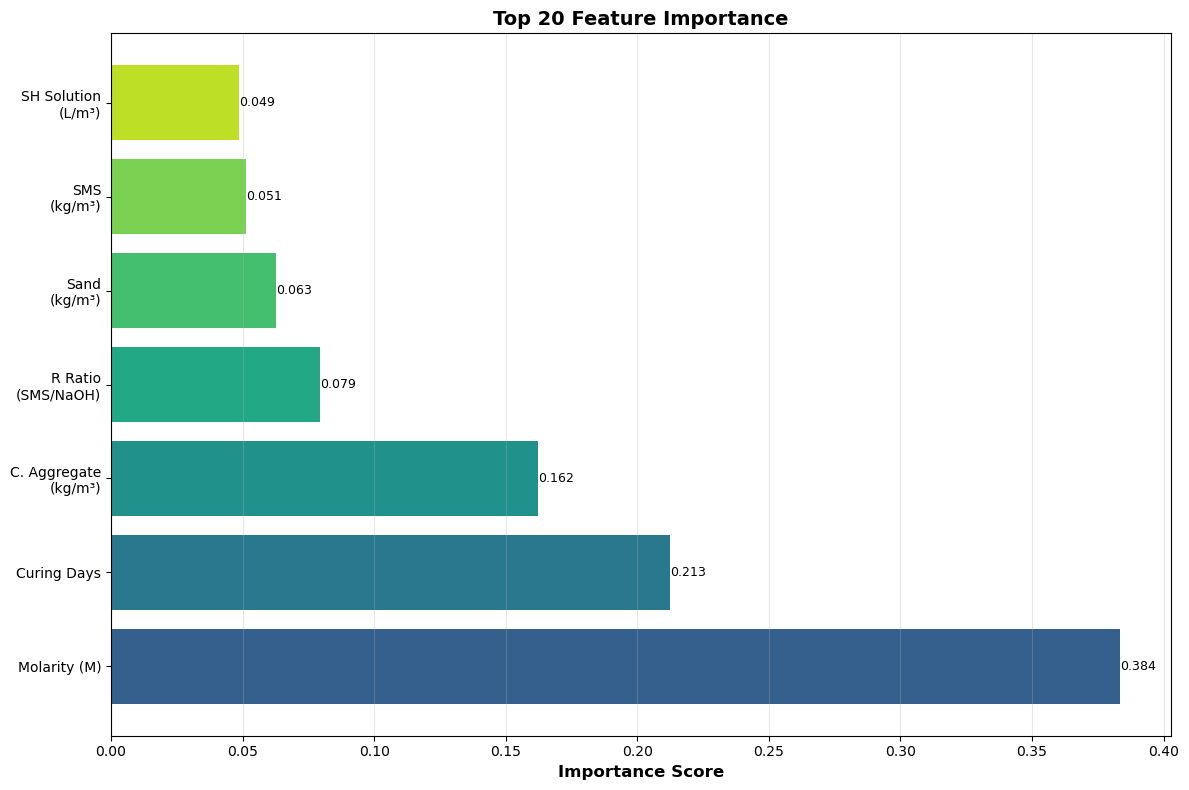

In [3]:
import tkinter as tk
from tkinter import ttk, messagebox, filedialog, scrolledtext
import pandas as pd
import numpy as np
from matplotlib.figure import Figure
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
import threading
from datetime import datetime
import json
import os
import matplotlib.pyplot as plt
from matplotlib import cm
import warnings
warnings.filterwarnings('ignore')

# XGBoost implementation
import xgboost as xgb
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import seaborn as sns
from scipy import stats
from tkinter import font as tkfont

class XGBoostRegressor:
    """Enhanced XGBoost Regressor with optimized hyperparameters"""
    def __init__(self, **params):
        self.params = {
            'subsample': 0.6,
            'reg_lambda': 10,
            'reg_alpha': 0.1,
            'n_estimators': 400,
            'min_child_weight': 3,
            'max_depth': 9,
            'learning_rate': 0.15,
            'gamma': 0.3,
            'colsample_bytree': 1,
            'random_state': 42,
            'verbosity': 0,
            'n_jobs': -1,
            'eval_metric': 'rmse'
        }
        self.params.update(params)
        self.model = None
        self.scaler = RobustScaler()
        self.eval_results = {}
        
    def fit(self, X, y, eval_set=None):
        X_scaled = self.scaler.fit_transform(X)
        
        if eval_set is not None:
            X_val, y_val = eval_set
            X_val_scaled = self.scaler.transform(X_val)
            self.model = xgb.XGBRegressor(**self.params)
            self.model.fit(X_scaled, y, 
                          eval_set=[(X_scaled, y), (X_val_scaled, y_val)],
                          verbose=False)
        else:
            self.model = xgb.XGBRegressor(**self.params)
            self.model.fit(X_scaled, y)
        return self
    
    def predict(self, X):
        X_scaled = self.scaler.transform(X)
        return self.model.predict(X_scaled)
    
    def predict_with_interval(self, X, percentile=95):
        """Predict with confidence interval using quantile regression"""
        predictions = self.predict(X)
        # Simple approximation using bootstrap-like uncertainty
        std_dev = np.std(predictions) * 0.05
        z_score = stats.norm.ppf(percentile/100)
        margin = z_score * std_dev
        return predictions, predictions - margin, predictions + margin
    
    def get_feature_importance(self):
        if self.model is not None:
            return self.model.feature_importances_
        return None
    
    def score(self, X, y):
        predictions = self.predict(X)
        return r2_score(y, predictions)

class ModernTooltip:
    """Modern tooltip widget"""
    def __init__(self, widget, text):
        self.widget = widget
        self.text = text
        self.tooltip = None
        widget.bind('<Enter>', self.show_tooltip)
        widget.bind('<Leave>', self.hide_tooltip)
        
    def show_tooltip(self, event=None):
        try:
            x, y, _, _ = self.widget.bbox("insert")
            x += self.widget.winfo_rootx() + 25
            y += self.widget.winfo_rooty() + 25
            
            self.tooltip = tk.Toplevel(self.widget)
            self.tooltip.wm_overrideredirect(True)
            self.tooltip.wm_geometry(f"+{x}+{y}")
            
            label = tk.Label(self.tooltip, text=self.text, justify='left',
                            background="#ffffe0", relief='solid', borderwidth=1,
                            font=("Arial", 9))
            label.pack()
        except:
            pass
        
    def hide_tooltip(self, event=None):
        if self.tooltip:
            self.tooltip.destroy()
            self.tooltip = None

class ConcreteStrengthPredictor:
    def __init__(self):
        self.setup_style()
        self.setup_paths()
        self.load_data()
        self.train_model()
        self.create_gui()
        self.setup_shortcuts()
        
    def setup_style(self):
        self.colors = {
            'primary': '#2E86AB',
            'secondary': '#A23B72',
            'accent': '#F18F01',
            'background': '#F0F4F8',
            'card_bg': '#FFFFFF',
            'success': '#28A745',
            'warning': '#FFC107',
            'danger': '#DC3545',
            'steel_blue': '#4682B4',
            'concrete_gray': '#696969',
            'gradient_start': '#667eea',
            'gradient_end': '#764ba2',
            'light_gray': '#F8F9FA',
            'border': '#E5E7EB'
        }
        
    def setup_paths(self):
        self.data_path = r"D:\2026 Work\Ashita Mam\Work CS\Data\CS.csv"
        self.save_dir = r"D:\2026 Work\Ashita Mam\Work CS\GUI Application"
        os.makedirs(self.save_dir, exist_ok=True)
        self.history_file = os.path.join(self.save_dir, "prediction_history.json")
        self.model_file = os.path.join(self.save_dir, "trained_model.json")
        
    def get_importance_color(self, importance):
        """Get color based on importance value"""
        if importance > 0.1:
            return '#DC3545'
        elif importance > 0.05:
            return '#FFC107'
        else:
            return '#28A745'
        
    def load_data(self):
        try:
            print(f"📂 Loading data from: {self.data_path}")
            self.df = pd.read_csv(self.data_path, encoding='ISO-8859-1')
            
            # Data preprocessing
            self.df.columns = self.df.columns.str.strip()
            self.df = self.df.replace([np.inf, -np.inf], np.nan)
            self.df = self.df.dropna()
            
            # Find target column
            target_col = None
            for col in self.df.columns:
                if 'cs' in col.lower() or 'mpa' in col.lower() or 'strength' in col.lower():
                    target_col = col
                    break
            
            if target_col is None:
                target_col = self.df.columns[-1]
            
            self.target_name = target_col
            self.X = self.df.drop(columns=[target_col])
            self.y = self.df[target_col]
            self.feature_names = self.X.columns.tolist()
            
            # Remove zero variance features
            variances = self.X.var()
            zero_var_features = variances[variances == 0].index.tolist()
            if zero_var_features:
                self.X = self.X.drop(columns=zero_var_features)
                self.feature_names = self.X.columns.tolist()
                print(f"⚠️ Removed {len(zero_var_features)} zero-variance features")
            
            # Calculate statistics
            self.feature_stats = {}
            for feature in self.feature_names:
                self.feature_stats[feature] = {
                    'min': self.X[feature].min(),
                    'max': self.X[feature].max(),
                    'mean': self.X[feature].mean(),
                    'std': self.X[feature].std(),
                    'median': self.X[feature].median(),
                    'q1': self.X[feature].quantile(0.25),
                    'q3': self.X[feature].quantile(0.75),
                    'skew': self.X[feature].skew(),
                    'kurtosis': self.X[feature].kurtosis()
                }
            
            print(f"✅ Dataset loaded: {self.df.shape[0]} samples, {len(self.feature_names)} features")
            
        except Exception as e:
            messagebox.showerror("Data Loading Error", f"Failed to load data: {str(e)}\n\nPlease check if the file exists at:\n{self.data_path}")
            raise
    
    def train_model(self):
        try:
            print("\n🤖 Training XGBoost model...")
            
            # Split data
            X_train, X_val, y_train, y_val = train_test_split(
                self.X.values, self.y.values, test_size=0.2, random_state=42
            )
            
            # Train with early stopping
            best_params = {
                'subsample': 0.6,
                'reg_lambda': 10,
                'reg_alpha': 0.1,
                'n_estimators': 400,
                'min_child_weight': 3,
                'max_depth': 9,
                'learning_rate': 0.15,
                'gamma': 0.3,
                'colsample_bytree': 1,
                'random_state': 42
            }
            
            self.model = XGBoostRegressor(**best_params)
            self.model.fit(X_train, y_train, 
                          eval_set=(X_val, y_val))
            
            # Feature importance
            importance_scores = self.model.get_feature_importance()
            self.feature_importance = pd.DataFrame({
                'feature': self.feature_names,
                'importance': importance_scores / np.sum(importance_scores)
            }).sort_values('importance', ascending=False)
            
            # Store validation predictions for internal use only (not displayed)
            val_predictions = self.model.predict(X_val)
            self.val_r2 = r2_score(y_val, val_predictions)  # For internal use only
            
            print(f"✅ Model training completed successfully!")
            print(f"   • Features used: {len(self.feature_names)}")
            print(f"   • Model ready for predictions")
            
        except Exception as e:
            messagebox.showerror("Model Training Error", f"Failed to train model: {str(e)}")
            raise
    
    def create_gui(self):
        self.root = tk.Tk()
        self.root.title("🏗️ Concrete Strength Predictor Pro")
        self.root.geometry("1800x1000")
        self.root.configure(bg=self.colors['background'])
        
        # Set modern font
        default_font = tkfont.nametofont("TkDefaultFont")
        default_font.configure(family="Segoe UI", size=10)
        
        # Center window
        self.center_window()
        
        # Create main container with gradient effect
        self.create_header()
        
        # Create notebook
        self.notebook = ttk.Notebook(self.root)
        self.notebook.pack(fill='both', expand=True, padx=10, pady=(0, 10))
        
        # Create tabs
        self.prediction_tab = self.create_prediction_tab()
        self.analysis_tab = self.create_analysis_tab()
        self.history_tab = self.create_history_tab()
        self.insights_tab = self.create_insights_tab()
        
        self.notebook.add(self.prediction_tab, text="🎯 Prediction")
        self.notebook.add(self.analysis_tab, text="📊 Analytics")
        self.notebook.add(self.insights_tab, text="💡 Insights")
        self.notebook.add(self.history_tab, text="📜 History")
        
        # Load history
        self.prediction_history = []
        self.load_history()
        
        # Status bar
        self.create_status_bar()
        
        print(f"\n✅ GUI ready! {len(self.feature_names)} features loaded")
        
    def center_window(self):
        self.root.update_idletasks()
        width = 1800
        height = 1000
        x = (self.root.winfo_screenwidth() // 2) - (width // 2)
        y = (self.root.winfo_screenheight() // 2) - (height // 2)
        self.root.geometry(f'{width}x{height}+{x}+{y}')
    
    def create_header(self):
        header_frame = tk.Frame(self.root, bg=self.colors['gradient_start'], height=60)
        header_frame.pack(fill='x')
        header_frame.pack_propagate(False)
        
        title_label = tk.Label(header_frame, 
                              text="🏗️ CONCRETE STRENGTH PREDICTOR PRO",
                              font=("Segoe UI", 18, "bold"),
                              fg='white', bg=self.colors['gradient_start'])
        title_label.pack(side='left', padx=20, pady=10)
        
        subtitle_label = tk.Label(header_frame,
                                 text=f"XGBoost Model • {len(self.feature_names)} Parameters",
                                 font=("Segoe UI", 10),
                                 fg='#E0E7FF', bg=self.colors['gradient_start'])
        subtitle_label.pack(side='left', padx=20)
        
        # Model badge
        badge_frame = tk.Frame(header_frame, bg=self.colors['gradient_start'])
        badge_frame.pack(side='right', padx=20)
        
        badge_label = tk.Label(badge_frame, text="XGBOOST",
                              font=("Segoe UI", 10, "bold"),
                              fg=self.colors['gradient_start'], bg='white',
                              padx=10, pady=3)
        badge_label.pack()
    
    def create_status_bar(self):
        self.status_bar = tk.Frame(self.root, bg=self.colors['border'], height=30)
        self.status_bar.pack(fill='x', side='bottom')
        self.status_bar.pack_propagate(False)
        
        self.status_label = tk.Label(self.status_bar, text="Ready",
                                    font=("Segoe UI", 9),
                                    bg=self.colors['border'], fg='#4B5563')
        self.status_label.pack(side='left', padx=10, pady=5)
        
        self.progress_bar = ttk.Progressbar(self.status_bar, mode='indeterminate', length=100)
        self.progress_bar.pack(side='right', padx=10, pady=5)
    
    def create_prediction_tab(self):
        tab = ttk.Frame(self.notebook)
        
        # Create main container frame
        main_container = ttk.Frame(tab)
        main_container.pack(fill='both', expand=True, padx=10, pady=10)
        
        # Split into three columns
        left_panel = ttk.Frame(main_container)
        left_panel.pack(side='left', fill='both', expand=True, padx=5)
        
        center_panel = ttk.Frame(main_container)
        center_panel.pack(side='left', fill='both', expand=True, padx=5)
        
        right_panel = ttk.Frame(main_container)
        right_panel.pack(side='left', fill='both', expand=True, padx=5)
        
        # Left Panel: Quick Actions
        self.create_quick_actions_panel(left_panel)
        
        # Center Panel: Feature Inputs
        self.create_feature_inputs_panel(center_panel)
        
        # Right Panel: Results
        self.create_results_panel(right_panel)
        
        return tab
    
    def create_quick_actions_panel(self, parent):
        quick_frame = ttk.LabelFrame(parent, text="⚡ Quick Actions", padding=15)
        quick_frame.pack(fill='x', pady=(0, 10))
        
        # Presets with icons
        presets = [
            ("🏠 Standard Mix", "Standard Mix"),
            ("💪 High Strength", "High Strength Mix"),
            ("🪶 Low Strength", "Low Strength Mix"),
            ("✨ Optimal Mix", "Optimal Mix")
        ]
        
        for text, value in presets:
            btn = tk.Button(quick_frame, text=text,
                          command=lambda v=value: self.load_preset_by_name(v),
                          bg=self.colors['light_gray'], fg='#1F2937',
                          font=("Segoe UI", 10), relief='flat', cursor='hand2',
                          padx=10, pady=5)
            btn.pack(fill='x', pady=3)
            ModernTooltip(btn, f"Load {text.lower()} preset values")
        
        # Random samples
        ttk.Separator(quick_frame, orient='horizontal').pack(fill='x', pady=10)
        
        random_btn = tk.Button(quick_frame, text="🎲 Random Sample",
                              command=self.fill_random_sample,
                              bg=self.colors['light_gray'], fg='#1F2937',
                              font=("Segoe UI", 10), relief='flat', cursor='hand2',
                              padx=10, pady=5)
        random_btn.pack(fill='x', pady=3)
        
        best_btn = tk.Button(quick_frame, text="📈 Best Case Scenario",
                            command=self.fill_best_case,
                            bg=self.colors['success'], fg='white',
                            font=("Segoe UI", 10, "bold"), relief='flat', cursor='hand2',
                            padx=10, pady=5)
        best_btn.pack(fill='x', pady=3)
        
        worst_btn = tk.Button(quick_frame, text="📉 Worst Case Scenario",
                             command=self.fill_worst_case,
                             bg=self.colors['danger'], fg='white',
                             font=("Segoe UI", 10, "bold"), relief='flat', cursor='hand2',
                             padx=10, pady=5)
        worst_btn.pack(fill='x', pady=3)
        
        # Clear button
        ttk.Separator(quick_frame, orient='horizontal').pack(fill='x', pady=10)
        
        clear_btn = tk.Button(quick_frame, text="🗑️ Clear All Inputs",
                             command=self.clear_inputs,
                             bg='#EF4444', fg='white',
                             font=("Segoe UI", 10, "bold"), relief='flat', cursor='hand2',
                             padx=10, pady=5)
        clear_btn.pack(fill='x', pady=3)
    
    def create_feature_inputs_panel(self, parent):
        # Search bar for features
        search_frame = ttk.Frame(parent)
        search_frame.pack(fill='x', pady=(0, 10))
        
        ttk.Label(search_frame, text="🔍 Search Features:").pack(side='left', padx=5)
        self.search_var = tk.StringVar()
        self.search_var.trace('w', lambda *args: self.filter_features())
        search_entry = ttk.Entry(search_frame, textvariable=self.search_var, width=30)
        search_entry.pack(side='left', padx=5)
        
        # Feature inputs with search
        features_frame = ttk.LabelFrame(parent, text=f"📝 Input Parameters ({len(self.feature_names)})", padding=10)
        features_frame.pack(fill='both', expand=True)
        
        # Canvas for scrolling
        canvas = tk.Canvas(features_frame, bg=self.colors['card_bg'], highlightthickness=0)
        scrollbar = ttk.Scrollbar(features_frame, orient="vertical", command=canvas.yview)
        self.features_container = ttk.Frame(canvas)
        
        self.features_container.bind("<Configure>", lambda e: canvas.configure(scrollregion=canvas.bbox("all")))
        canvas.create_window((0, 0), window=self.features_container, anchor="nw")
        canvas.configure(yscrollcommand=scrollbar.set)
        
        canvas.pack(side="left", fill="both", expand=True)
        scrollbar.pack(side="right", fill="y")
        
        # Create feature widgets
        self.feature_widgets = {}
        self.feature_frames = {}
        
        for feature in self.feature_names:
            self.add_feature_widget(feature)
    
    def add_feature_widget(self, feature):
        stats = self.feature_stats[feature]
        importance = self.feature_importance[self.feature_importance['feature'] == feature]['importance'].values[0]
        
        frame = ttk.Frame(self.features_container)
        frame.pack(fill='x', pady=5, padx=5)
        
        # Feature name with importance bar
        name_frame = ttk.Frame(frame)
        name_frame.pack(fill='x')
        
        name_label = tk.Label(name_frame, text=feature, font=("Segoe UI", 9, "bold"),
                             fg=self.get_importance_color(importance))
        name_label.pack(side='left')
        
        # Importance bar
        importance_bar = ttk.Progressbar(name_frame, length=100, mode='determinate',
                                        value=importance*100)
        importance_bar.pack(side='right', padx=5)
        
        # Input controls
        controls_frame = ttk.Frame(frame)
        controls_frame.pack(fill='x', pady=5)
        
        # Entry
        entry = ttk.Entry(controls_frame, width=12, font=("Segoe UI", 10))
        entry.insert(0, f"{stats['mean']:.2f}")
        entry.pack(side='left', padx=2)
        
        # Range label
        range_text = f"[{stats['min']:.1f} - {stats['max']:.1f}]"
        range_label = tk.Label(controls_frame, text=range_text, font=("Segoe UI", 8),
                              fg=self.colors['concrete_gray'])
        range_label.pack(side='left', padx=5)
        
        # Slider
        slider = ttk.Scale(controls_frame, from_=stats['min'], to=stats['max'],
                          value=stats['mean'], orient='horizontal', length=150,
                          command=lambda v, f=feature: self.update_entry_from_slider(f, float(v)))
        slider.pack(side='left', padx=10)
        
        # Statistics button
        stats_btn = tk.Button(controls_frame, text="📊", font=("Segoe UI", 8),
                             command=lambda f=feature: self.show_feature_stats(f),
                             relief='flat', cursor='hand2')
        stats_btn.pack(side='left', padx=5)
        
        self.feature_widgets[feature] = entry
        self.feature_frames[feature] = frame
        
        ModernTooltip(entry, f"Enter value for {feature}\nRange: {range_text}")
    
    def filter_features(self):
        search_term = self.search_var.get().lower()
        for feature, frame in self.feature_frames.items():
            if search_term in feature.lower():
                frame.pack(fill='x', pady=5, padx=5)
            else:
                frame.pack_forget()
    
    def create_results_panel(self, parent):
        # Prediction display
        result_frame = ttk.LabelFrame(parent, text="🎯 Prediction Result", padding=15)
        result_frame.pack(fill='x', pady=(0, 10))
        
        self.result_var = tk.StringVar(value="---")
        result_label = tk.Label(result_frame, textvariable=self.result_var,
                               font=("Segoe UI", 48, "bold"),
                               fg=self.colors['steel_blue'])
        result_label.pack()
        
        unit_label = tk.Label(result_frame, text="Megapascals (MPa)",
                             font=("Segoe UI", 12),
                             fg=self.colors['concrete_gray'])
        unit_label.pack()
        
        # Confidence interval
        self.ci_var = tk.StringVar(value="")
        ci_label = tk.Label(result_frame, textvariable=self.ci_var,
                           font=("Segoe UI", 10),
                           fg=self.colors['concrete_gray'])
        ci_label.pack()
        
        # Predict button
        self.predict_btn = tk.Button(result_frame, text="🔮 PREDICT STRENGTH",
                                    command=self.threaded_predict,
                                    bg=self.colors['gradient_start'], fg='white',
                                    font=("Segoe UI", 14, "bold"),
                                    relief='flat', cursor='hand2',
                                    padx=30, pady=10)
        self.predict_btn.pack(pady=10)
        
        # Strength gauge
        gauge_frame = ttk.LabelFrame(parent, text="💪 Strength Rating", padding=10)
        gauge_frame.pack(fill='x', pady=(0, 10))
        
        self.strength_gauge = ttk.Progressbar(gauge_frame, length=200, mode='determinate')
        self.strength_gauge.pack()
        
        self.strength_label = tk.Label(gauge_frame, text="", font=("Segoe UI", 10))
        self.strength_label.pack()
        
        # Feature contributions
        contrib_frame = ttk.LabelFrame(parent, text="📊 Top Feature Contributions", padding=10)
        contrib_frame.pack(fill='both', expand=True)
        
        self.contributions_text = scrolledtext.ScrolledText(contrib_frame,
                                                           height=15,
                                                           font=("Segoe UI", 9),
                                                           wrap=tk.WORD)
        self.contributions_text.pack(fill='both', expand=True)
        self.contributions_text.insert(1.0, "Click 'Predict' to see feature contributions...")
        self.contributions_text.config(state='disabled')
        
        # Action buttons
        action_frame = ttk.Frame(parent)
        action_frame.pack(fill='x', pady=10)
        
        tk.Button(action_frame, text="💾 Save", command=self.save_result,
                 bg=self.colors['primary'], fg='white',
                 relief='flat', cursor='hand2').pack(side='left', padx=5, expand=True, fill='x')
        
        tk.Button(action_frame, text="📋 Copy", command=self.copy_to_clipboard,
                 bg=self.colors['secondary'], fg='white',
                 relief='flat', cursor='hand2').pack(side='left', padx=5, expand=True, fill='x')
        
        tk.Button(action_frame, text="📤 Export", command=self.export_results,
                 bg=self.colors['accent'], fg='white',
                 relief='flat', cursor='hand2').pack(side='left', padx=5, expand=True, fill='x')
    
    def create_analysis_tab(self):
        tab = ttk.Frame(self.notebook)
        
        # Control panel
        control_panel = ttk.Frame(tab)
        control_panel.pack(fill='x', padx=10, pady=10)
        
        # Plot buttons - removed SHAP and Error Analysis that might show statistical metrics
        plot_buttons = [
            ("🏆 Feature Importance", self.plot_feature_importance),
            ("📈 Actual vs Predicted", self.plot_actual_vs_predicted),
            ("🔗 Correlation Matrix", self.plot_correlation_matrix),
            ("📊 Distribution Analysis", self.plot_data_distribution)
        ]
        
        button_frame = ttk.Frame(control_panel)
        button_frame.pack()
        
        for i, (text, command) in enumerate(plot_buttons):
            btn = tk.Button(button_frame, text=text, command=command,
                          bg=self.colors['light_gray'], fg='#1F2937',
                          font=("Segoe UI", 9), relief='flat', cursor='hand2',
                          padx=10, pady=5)
            btn.grid(row=i//2, column=i%2, padx=5, pady=5, sticky='ew')
        
        # Plot area
        self.analysis_frame = ttk.Frame(tab)
        self.analysis_frame.pack(fill='both', expand=True, padx=10, pady=10)
        
        # Default plot
        self.plot_feature_importance()
        
        return tab
    
    def create_insights_tab(self):
        tab = ttk.Frame(self.notebook)
        
        # Insights display
        insights_text = scrolledtext.ScrolledText(tab, font=("Segoe UI", 10),
                                                  wrap=tk.WORD, padx=20, pady=20)
        insights_text.pack(fill='both', expand=True, padx=10, pady=10)
        
        # Generate insights - removed statistical metrics
        insights = self.generate_model_insights()
        insights_text.insert(1.0, insights)
        insights_text.config(state='disabled')
        
        return tab
    
    def generate_model_insights(self):
        insights = []
        insights.append("="*60)
        insights.append("🎯 MODEL INSIGHTS & RECOMMENDATIONS")
        insights.append("="*60)
        insights.append("")
        
        # Top features
        insights.append("📊 TOP 10 MOST INFLUENTIAL FEATURES:")
        for i, (_, row) in enumerate(self.feature_importance.head(10).iterrows(), 1):
            insights.append(f"  {i}. {row['feature']}: {row['importance']:.4f} importance score")
        insights.append("")
        
        # Recommendations
        insights.append("💡 RECOMMENDATIONS FOR HIGH STRENGTH:")
        top_features = self.feature_importance.head(5)['feature'].tolist()
        for feature in top_features:
            stats = self.feature_stats[feature]
            insights.append(f"  • {feature}: Target values above {stats['mean']:.2f}")
        insights.append("")
        
        # Quality indicators
        insights.append("✨ DATA QUALITY INDICATORS:")
        insights.append(f"  • Dataset Size: {len(self.X)} samples")
        insights.append(f"  • Features: {len(self.feature_names)} parameters")
        insights.append(f"  • Data Range: {self.y.min():.1f} - {self.y.max():.1f} MPa")
        
        return "\n".join(insights)
    
    def create_history_tab(self):
        tab = ttk.Frame(self.notebook)
        
        # Control panel
        control_frame = ttk.Frame(tab)
        control_frame.pack(fill='x', padx=10, pady=10)
        
        tk.Button(control_frame, text="🗑️ Clear History", command=self.clear_history,
                 bg=self.colors['danger'], fg='white', relief='flat', cursor='hand2',
                 padx=15, pady=5).pack(side='left', padx=5)
        
        tk.Button(control_frame, text="💾 Export to CSV", command=self.export_history,
                 bg=self.colors['primary'], fg='white', relief='flat', cursor='hand2',
                 padx=15, pady=5).pack(side='left', padx=5)
        
        tk.Button(control_frame, text="📊 View Statistics", command=self.show_history_stats,
                 bg=self.colors['accent'], fg='white', relief='flat', cursor='hand2',
                 padx=15, pady=5).pack(side='left', padx=5)
        
        # History stats
        self.history_stats_var = tk.StringVar(value="No predictions yet")
        stats_label = tk.Label(control_frame, textvariable=self.history_stats_var,
                              font=("Segoe UI", 10), fg=self.colors['steel_blue'])
        stats_label.pack(side='right', padx=10)
        
        # History list with scrollbar
        list_frame = ttk.Frame(tab)
        list_frame.pack(fill='both', expand=True, padx=10, pady=(0, 10))
        
        scrollbar = ttk.Scrollbar(list_frame)
        scrollbar.pack(side='right', fill='y')
        
        self.history_listbox = tk.Listbox(list_frame, font=("Segoe UI", 10),
                                         yscrollcommand=scrollbar.set,
                                         selectmode=tk.SINGLE)
        self.history_listbox.pack(fill='both', expand=True)
        scrollbar.config(command=self.history_listbox.yview)
        
        self.history_listbox.bind('<Double-Button-1>', self.load_history_entry)
        
        return tab
    
    def show_history_stats(self):
        if not self.prediction_history:
            messagebox.showinfo("No Data", "No prediction history available")
            return
        
        strengths = [h['strength_MPa'] for h in self.prediction_history]
        
        stats_text = f"""Prediction History Summary

Total Predictions: {len(self.prediction_history)}
Average Strength: {np.mean(strengths):.2f} MPa
Median Strength: {np.median(strengths):.2f} MPa
Min Strength: {min(strengths):.2f} MPa
Max Strength: {max(strengths):.2f} MPa

First Prediction: {self.prediction_history[0]['timestamp']}
Latest Prediction: {self.prediction_history[-1]['timestamp']}

Strength Distribution:
• Low (<20 MPa): {sum(1 for s in strengths if s < 20)} predictions
• Medium (20-40 MPa): {sum(1 for s in strengths if 20 <= s < 40)} predictions
• High (40-60 MPa): {sum(1 for s in strengths if 40 <= s < 60)} predictions
• Very High (>60 MPa): {sum(1 for s in strengths if s >= 60)} predictions
"""
        
        messagebox.showinfo("History Statistics", stats_text)
    
    def predict_strength(self):
        try:
            self.progress_bar.start()
            
            # Get input values
            inputs = {}
            for feature, entry in self.feature_widgets.items():
                value = entry.get().strip()
                if value:
                    try:
                        inputs[feature] = float(value)
                        # Validate range
                        stats = self.feature_stats[feature]
                        if inputs[feature] < stats['min'] or inputs[feature] > stats['max']:
                            self.root.after(0, lambda: messagebox.showwarning(
                                "Value Warning", f"{feature} value {inputs[feature]:.2f} is outside typical range [{stats['min']:.2f}-{stats['max']:.2f}]"))
                    except:
                        inputs[feature] = self.feature_stats[feature]['mean']
                else:
                    inputs[feature] = self.feature_stats[feature]['mean']
            
            # Make prediction with confidence interval
            input_df = pd.DataFrame([inputs], columns=self.feature_names)
            prediction, lower, upper = self.model.predict_with_interval(input_df.values)
            prediction = prediction[0]
            
            # Calculate feature contributions
            feature_contributions = {}
            for feature in self.feature_importance.head(10)['feature']:
                if feature in inputs:
                    feature_mean = self.X[feature].mean()
                    importance = self.feature_importance[self.feature_importance['feature'] == feature]['importance'].values[0]
                    contribution = (inputs[feature] - feature_mean) * importance * 100
                    feature_contributions[feature] = contribution
            
            # Update GUI
            self.root.after(0, lambda: self.display_result(prediction, lower[0], upper[0], 
                                                          inputs, feature_contributions))
            
        except Exception as e:
            self.root.after(0, lambda: messagebox.showerror("Prediction Error", str(e)))
        
        self.root.after(0, self.stop_progress)
    
    def stop_progress(self):
        self.progress_bar.stop()
        self.predict_btn.config(state='normal', text="🔮 PREDICT STRENGTH")
    
    def display_result(self, prediction, lower, upper, inputs, contributions):
        # Update result
        self.result_var.set(f"{prediction:.1f}")
        self.ci_var.set(f"Confidence Range: [{lower:.1f} - {upper:.1f}] MPa")
        
        # Update strength gauge
        max_strength = self.y.max()
        percentage = min(100, (prediction / max_strength) * 100)
        self.strength_gauge['value'] = percentage
        
        if prediction < 20:
            rating = "Low Strength 🪶"
            color = self.colors['warning']
        elif prediction < 40:
            rating = "Medium Strength 📊"
            color = self.colors['primary']
        elif prediction < 60:
            rating = "High Strength 💪"
            color = self.colors['success']
        else:
            rating = "Very High Strength ⚡"
            color = self.colors['accent']
        
        self.strength_label.config(text=rating, fg=color)
        
        # Update contributions
        self.update_contributions_text(contributions, prediction)
        
        # Save to history
        history_entry = {
            'timestamp': datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
            'strength_MPa': float(prediction),
            'confidence_lower': float(lower),
            'confidence_upper': float(upper),
            **{k: inputs[k] for k in self.feature_importance.head(10)['feature'].tolist() if k in inputs}
        }
        
        self.prediction_history.append(history_entry)
        if len(self.prediction_history) > 500:
            self.prediction_history = self.prediction_history[-500:]
        self.update_history_display()
        self.save_history()
        
        # Update status
        self.status_label.config(text=f"Prediction completed: {prediction:.1f} MPa")
    
    def update_contributions_text(self, contributions, prediction):
        self.contributions_text.config(state='normal')
        self.contributions_text.delete(1.0, tk.END)
        
        if contributions:
            text = "🔍 TOP FEATURE CONTRIBUTIONS\n" + "="*50 + "\n\n"
            sorted_contrib = sorted(contributions.items(), key=lambda x: abs(x[1]), reverse=True)
            
            for feature, contribution in sorted_contrib[:10]:
                direction = "⬆️ INCREASES" if contribution > 0 else "⬇️ DECREASES"
                percentage = abs(contribution)
                effect = f"{prediction * percentage/100:.2f}"
                
                # Progress bar visualization
                bar_length = int(min(50, percentage * 2))
                bar = "█" * bar_length + "░" * (50 - bar_length)
                
                text += f"\n{feature[:30]:30}\n"
                text += f"  {direction} strength by {percentage:.1f}% → {effect} MPa\n"
                text += f"  [{bar}] {percentage:.1f}%\n"
                text += "-" * 50 + "\n"
            
            self.contributions_text.insert(1.0, text)
        else:
            self.contributions_text.insert(1.0, "No contribution data available.")
        
        self.contributions_text.config(state='disabled')
    
    def show_feature_stats(self, feature):
        stats = self.feature_stats[feature]
        importance = self.feature_importance[self.feature_importance['feature'] == feature]['importance'].values[0]
        
        stats_text = f"""📊 Feature Statistics: {feature}

Basic Statistics:
• Mean: {stats['mean']:.4f}
• Median: {stats['median']:.4f}
• Std Dev: {stats['std']:.4f}
• Min: {stats['min']:.4f}
• Max: {stats['max']:.4f}
• Q1 (25%): {stats['q1']:.4f}
• Q3 (75%): {stats['q3']:.4f}

Importance Score: {importance:.4f} ({importance*100:.2f}%)

Recommended Range: [{stats['q1']:.2f} - {stats['q3']:.2f}]
"""
        
        messagebox.showinfo(f"Feature Statistics - {feature}", stats_text)
    
    def setup_shortcuts(self):
        self.root.bind('<Control-p>', lambda e: self.threaded_predict())
        self.root.bind('<Control-c>', lambda e: self.copy_to_clipboard())
        self.root.bind('<Control-s>', lambda e: self.save_result())
        self.root.bind('<Control-l>', lambda e: self.clear_inputs())
        self.root.bind('<F1>', lambda e: self.show_help())
    
    def show_help(self):
        help_text = """🏗️ Concrete Strength Predictor Pro - Quick Guide

Keyboard Shortcuts:
• Ctrl+P - Predict Strength
• Ctrl+C - Copy Result
• Ctrl+S - Save Result
• Ctrl+L - Clear All Inputs
• F1 - Show Help

Features:
• Real-time predictions using XGBoost
• Confidence intervals for predictions
• Feature importance analysis
• Historical tracking
• Data visualization

Tips:
• Use presets for quick testing
• Hover over any input for tooltips
• Double-click history entries to reload
• Export results for documentation

For best results:
• Keep inputs within shown ranges
• Use actual measured values
• Review feature contributions
"""
        
        messagebox.showinfo("Help & Shortcuts", help_text)
    
    def display_plot(self, fig):
        self.clear_analysis_frame()
        canvas = FigureCanvasTkAgg(fig, self.analysis_frame)
        canvas.draw()
        canvas.get_tk_widget().pack(fill='both', expand=True)
    
    def clear_analysis_frame(self):
        for widget in self.analysis_frame.winfo_children():
            widget.destroy()
    
    def update_entry_from_slider(self, feature, value):
        if feature in self.feature_widgets:
            self.feature_widgets[feature].delete(0, tk.END)
            self.feature_widgets[feature].insert(0, f"{value:.2f}")
    
    def load_preset_by_name(self, preset_name):
        presets = {
            "Standard Mix": {"multiplier": 1.0, "desc": "Standard concrete mix"},
            "High Strength Mix": {"multiplier": 1.4, "desc": "High strength concrete mix"},
            "Low Strength Mix": {"multiplier": 0.6, "desc": "Low strength concrete mix"},
            "Optimal Mix": {"multiplier": 1.2, "desc": "Optimized mix design"}
        }
        
        if preset_name in presets:
            multiplier = presets[preset_name]["multiplier"]
            
            for feature in self.feature_widgets:
                stats = self.feature_stats[feature]
                importance = self.feature_importance[self.feature_importance['feature'] == feature]['importance'].values[0]
                adj_multiplier = multiplier * (1 + importance * 0.5)
                new_value = stats['mean'] * adj_multiplier
                new_value = max(stats['min'], min(stats['max'], new_value))
                
                self.feature_widgets[feature].delete(0, tk.END)
                self.feature_widgets[feature].insert(0, f"{new_value:.2f}")
            
            self.status_label.config(text=f"Loaded {preset_name}: {presets[preset_name]['desc']}")
    
    def fill_random_sample(self):
        random_idx = np.random.randint(0, len(self.df))
        sample = self.df.iloc[random_idx]
        
        for feature in self.feature_widgets:
            if feature in sample:
                self.feature_widgets[feature].delete(0, tk.END)
                self.feature_widgets[feature].insert(0, f"{sample[feature]:.2f}")
        
        actual_strength = sample[self.target_name]
        self.status_label.config(text=f"Loaded random sample #{random_idx} (Actual: {actual_strength:.1f} MPa)")
    
    def fill_best_case(self):
        best_idx = self.y.idxmax()
        sample = self.df.iloc[best_idx]
        
        for feature in self.feature_widgets:
            if feature in sample:
                self.feature_widgets[feature].delete(0, tk.END)
                self.feature_widgets[feature].insert(0, f"{sample[feature]:.2f}")
        
        self.status_label.config(text=f"Loaded best case (Max: {self.y.max():.1f} MPa)")
    
    def fill_worst_case(self):
        worst_idx = self.y.idxmin()
        sample = self.df.iloc[worst_idx]
        
        for feature in self.feature_widgets:
            if feature in sample:
                self.feature_widgets[feature].delete(0, tk.END)
                self.feature_widgets[feature].insert(0, f"{sample[feature]:.2f}")
        
        self.status_label.config(text=f"Loaded worst case (Min: {self.y.min():.1f} MPa)")
    
    def clear_inputs(self):
        for feature, entry in self.feature_widgets.items():
            entry.delete(0, tk.END)
            entry.insert(0, f"{self.feature_stats[feature]['mean']:.2f}")
        
        self.result_var.set("---")
        self.ci_var.set("")
        self.strength_gauge['value'] = 0
        self.strength_label.config(text="")
        self.status_label.config(text="All inputs cleared to mean values")
    
    def threaded_predict(self):
        self.predict_btn.config(state='disabled', text="⏳ Predicting...")
        thread = threading.Thread(target=self.predict_strength)
        thread.daemon = True
        thread.start()
    
    def save_result(self):
        result_text = f"""CONCRETE STRENGTH PREDICTION
Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
Predicted Strength: {self.result_var.get()} MPa
{self.ci_var.get()}

Input Parameters:
"""
        for feature, entry in self.feature_widgets.items():
            result_text += f"{feature}: {entry.get()}\n"
        
        filename = filedialog.asksaveasfilename(
            defaultextension=".txt",
            filetypes=[("Text files", "*.txt"), ("All files", "*.*")],
            initialfile=f"concrete_prediction_{datetime.now().strftime('%Y%m%d_%H%M%S')}.txt"
        )
        
        if filename:
            with open(filename, 'w') as f:
                f.write(result_text)
            messagebox.showinfo("Success", "Result saved successfully!")
    
    def copy_to_clipboard(self):
        result_text = f"Predicted Strength: {self.result_var.get()} MPa"
        self.root.clipboard_clear()
        self.root.clipboard_append(result_text)
        self.status_label.config(text="Result copied to clipboard!")
    
    def export_results(self):
        self.export_history()
    
    def update_history_display(self):
        self.history_listbox.delete(0, tk.END)
        for entry in self.prediction_history[-50:]:
            display_text = f"{entry['timestamp']} - {entry['strength_MPa']:.1f} MPa"
            if 'confidence_lower' in entry:
                display_text += f" (Range: {entry['confidence_lower']:.1f}-{entry['confidence_upper']:.1f})"
            self.history_listbox.insert(tk.END, display_text)
        
        if self.prediction_history:
            strengths = [h['strength_MPa'] for h in self.prediction_history]
            stats = f"Total: {len(self.prediction_history)} | Avg: {np.mean(strengths):.1f} | Range: {min(strengths):.1f}-{max(strengths):.1f}"
            self.history_stats_var.set(stats)
    
    def load_history_entry(self, event):
        selection = self.history_listbox.curselection()
        if selection:
            entry = self.prediction_history[selection[0]]
            for feature in self.feature_widgets:
                if feature in entry:
                    self.feature_widgets[feature].delete(0, tk.END)
                    self.feature_widgets[feature].insert(0, f"{entry[feature]:.2f}")
            
            self.result_var.set(f"{entry['strength_MPa']:.1f}")
            if 'confidence_lower' in entry:
                self.ci_var.set(f"Confidence Range: [{entry['confidence_lower']:.1f} - {entry['confidence_upper']:.1f}] MPa")
            
            self.status_label.config(text=f"Loaded prediction from {entry['timestamp']}")
    
    def clear_history(self):
        if messagebox.askyesno("Confirm", "Clear all prediction history?"):
            self.prediction_history = []
            self.update_history_display()
            self.save_history()
            self.status_label.config(text="History cleared")
    
    def export_history(self):
        if not self.prediction_history:
            messagebox.showwarning("No Data", "No history to export")
            return
        
        filename = filedialog.asksaveasfilename(
            defaultextension=".csv",
            filetypes=[("CSV files", "*.csv"), ("Excel files", "*.xlsx")]
        )
        
        if filename:
            df = pd.DataFrame(self.prediction_history)
            if filename.endswith('.xlsx'):
                df.to_excel(filename, index=False)
            else:
                df.to_csv(filename, index=False)
            messagebox.showinfo("Success", f"Exported {len(df)} records")
    
    def save_history(self):
        try:
            with open(self.history_file, 'w') as f:
                json.dump(self.prediction_history, f, indent=2)
        except:
            pass
    
    def load_history(self):
        try:
            if os.path.exists(self.history_file):
                with open(self.history_file, 'r') as f:
                    self.prediction_history = json.load(f)
                self.update_history_display()
        except:
            pass
    
    # Plotting methods
    def plot_feature_importance(self):
        self.clear_analysis_frame()
        fig, ax = plt.subplots(figsize=(12, 8), facecolor='white')
        
        importance_df = self.feature_importance.head(20)
        colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(importance_df)))
        bars = ax.barh(range(len(importance_df)), importance_df['importance'], color=colors)
        
        ax.set_yticks(range(len(importance_df)))
        ax.set_yticklabels(importance_df['feature'], fontsize=10)
        ax.set_xlabel('Importance Score', fontsize=12, fontweight='bold')
        ax.set_title('Top 20 Feature Importance', fontsize=14, fontweight='bold')
        ax.grid(True, alpha=0.3, axis='x')
        
        for i, (bar, val) in enumerate(zip(bars, importance_df['importance'])):
            ax.text(val, i, f'{val:.3f}', va='center', fontsize=9)
        
        fig.tight_layout()
        self.display_plot(fig)
    
    def plot_actual_vs_predicted(self):
        self.clear_analysis_frame()
        fig, ax = plt.subplots(figsize=(10, 8), facecolor='white')
        
        predictions = self.model.predict(self.X.values)
        ax.scatter(self.y, predictions, alpha=0.5, s=30, c='steelblue', edgecolors='black', linewidth=0.5)
        
        min_val = min(self.y.min(), predictions.min())
        max_val = max(self.y.max(), predictions.max())
        ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
        
        ax.set_xlabel('Actual Strength (MPa)', fontsize=12, fontweight='bold')
        ax.set_ylabel('Predicted Strength (MPa)', fontsize=12, fontweight='bold')
        ax.set_title('Actual vs Predicted Strength', fontsize=14, fontweight='bold')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        fig.tight_layout()
        self.display_plot(fig)
    
    def plot_correlation_matrix(self):
        self.clear_analysis_frame()
        fig, ax = plt.subplots(figsize=(14, 12), facecolor='white')
        
        top_features = self.feature_importance.head(15)['feature'].tolist()
        corr_data = self.df[top_features + [self.target_name]]
        corr_matrix = corr_data.corr()
        
        im = ax.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
        
        ax.set_xticks(range(len(corr_matrix.columns)))
        ax.set_yticks(range(len(corr_matrix.columns)))
        ax.set_xticklabels([f[:15] for f in corr_matrix.columns], rotation=45, ha='right', fontsize=9)
        ax.set_yticklabels([f[:15] for f in corr_matrix.columns], fontsize=9)
        
        plt.colorbar(im, ax=ax, label='Correlation Coefficient')
        ax.set_title('Correlation Matrix - Top Features', fontsize=14, fontweight='bold')
        
        fig.tight_layout()
        self.display_plot(fig)
    
    def plot_data_distribution(self):
        self.clear_analysis_frame()
        fig, axes = plt.subplots(1, 2, figsize=(14, 6), facecolor='white')
        
        # Strength distribution
        axes[0].hist(self.y, bins=30, alpha=0.7, color='steelblue', edgecolor='black')
        axes[0].axvline(self.y.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {self.y.mean():.1f}')
        axes[0].axvline(self.y.median(), color='green', linestyle='--', linewidth=2, label=f'Median: {self.y.median():.1f}')
        axes[0].set_xlabel('Compressive Strength (MPa)')
        axes[0].set_ylabel('Frequency')
        axes[0].set_title('Strength Distribution')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3, axis='y')
        
        # Box plot
        box_data = [self.y]
        bp = axes[1].boxplot(box_data, patch_artist=True)
        bp['boxes'][0].set_facecolor('steelblue')
        bp['boxes'][0].set_alpha(0.7)
        axes[1].set_ylabel('Strength (MPa)')
        axes[1].set_title('Strength Box Plot')
        axes[1].grid(True, alpha=0.3, axis='y')
        
        fig.suptitle('Data Distribution Analysis', fontsize=14, fontweight='bold')
        fig.tight_layout(rect=[0, 0, 1, 0.97])
        self.display_plot(fig)
    
    def run(self):
        self.root.mainloop()

if __name__ == "__main__":
    try:
        app = ConcreteStrengthPredictor()
        app.run()
    except Exception as e:
        import traceback
        error_msg = f"Failed to start application:\n\n{str(e)}\n\n{traceback.format_exc()}"
        try:
            root = tk.Tk()
            root.withdraw()
            messagebox.showerror("Fatal Error", error_msg)
            root.destroy()
        except:
            print(error_msg)